# 2.0.0 Demographics Calculator Demonstration
This notebook demonstrates the demographics calculator with the version 2.0.0 of the dataset.  

In [1]:
from rr_connection_manager import PostgresConnection

conn = PostgresConnection(app = "ukrdc_staging", tunnel = True, via_app = True)
conn.connection_check()
sessionmaker = conn.session_maker()

C:\Users\philip.main\Source\dashboard-stats\demo
[]
R:\Connection Manager\philip_main\philip_main.kdbx
e949624178735fdb977b03340af74e5c973d0384981e62f3a79ad21abbf28d87
None
None
True

Connection to ukrdc_staging successful. 
Database info: 
	PostgreSQL 9.6.24 on x86_64-pc-linux-gnu


# Running Stats and Getting a Response
The following cell demonstrates the basic syntax for running the stats calculator and what the response looks like. These return objects are designed to be both api friendly and easy to use in a stand alone context. Within each object is should be enough metadata to explain exactly what it is and how to use it. 

In [2]:
from ukrdc_stats.calculators.demographics import DemographicStatsCalculator
import json
import datetime as dt


with sessionmaker() as session:
    calculator = DemographicStatsCalculator(session, facility="RJZ", date = dt.datetime.now())
    #output = calculator.extract_stats(ukrr_expanded = True)
    output = calculator.extract_stats(ukrr_expanded = False)

# results are returned as pydantic object. To make these easier to 
formatted_output = json.dumps(
    json.loads(
        output.json()
    ), 
    indent=4
)

print(formatted_output)

NameError: name 'sessionmaker' is not defined

In [1]:
from importlib.metadata import metadata
import plotly.express as px
from IPython.display import display, Markdown


display(Markdown(output.age.metadata.description))

age_distribution = px.bar(
    x=output.age.data.x,
    y=output.age.data.y,
    title=output.age.metadata.title,
    labels={
        "x": output.age.metadata.axis_titles.x,
        "y": output.age.metadata.axis_titles.y,
    },
)
age_distribution.show()



NameError: name 'output' is not defined


# Patient Gender
Gender identity recorded for each living patient registered with the renal unit. Specifically it is defined as the person stated gender code in the nhs data dictionary

# Methodology

- The initial cohort is selected by filtering the patientrecords sent via the ukrdc.  
- The cohort is filtered to only include patients with a treatment record which overlaps 90 days prior to the calculation time. 

- Patient records are matched to NHS stated gender using patient demographic information 
- Patients are optionally checked against NHS tracing to check for date of death
- All living patients with patient records sent by a particular sending facility are aggregated based on gender


## UKRDC Entities Used
- [PatientRecord](https://renalregistry.atlassian.net/l/cp/KCZ6A2bX)
- [Patient](https://renalregistry.atlassian.net/l/cp/0MXHtpTU)



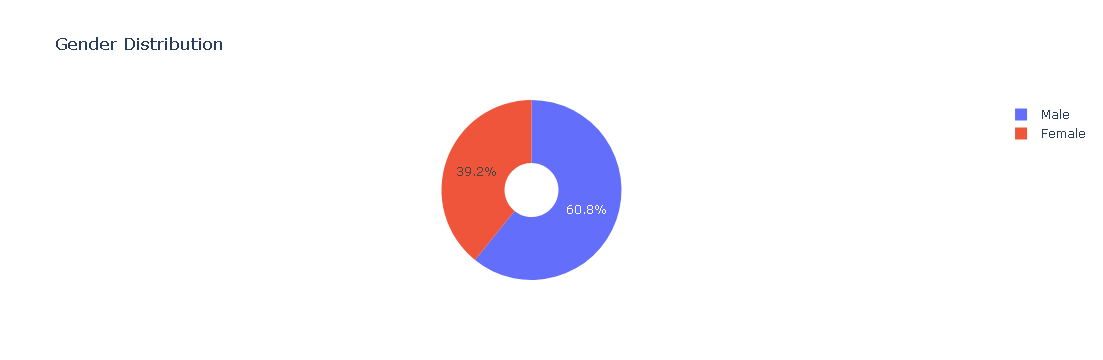

In [4]:
display(Markdown(output.gender.metadata.description))

gender_fig = px.pie(
    values=output.gender.data.y,
    names=output.gender.data.x,
    title=output.gender.metadata.title,
    hole=0.3,
)

gender_fig.show()



In [5]:
display(Markdown(output.ethnic_group.metadata.description))

# plot bar charts of some other bits
ethnicity_fig = px.pie(
    values=output.ethnic_group.data.y,
    names=output.ethnic_group.data.x,
    title=output.ethnic_group.metadata.title,
    hole=0.3,
)
ethnicity_fig.show()


# Patient Ethnicity

## Overview 
Ethnicity group code recorded for each living patient registered with the renal unit over all time.
The five ethnicity groupings used to map ethnicity codes onto the displayed ethnicity values are the same as those used in the Renal Registry Annual Report.

## Methodology

- The initial cohort is selected by filtering the patientrecords sent via the ukrdc.  
- The cohort is filtered to only include patients with a treatment record which overlaps 90 days prior to the calculation time. 

- Patient records are matched to ethnicity using patient demographic information 
- Patients are optionally checked against NHS tracing to check for date of death
- All living patients with patient records sent by a particular sending facility are aggregated based on ethnicity

## UKRDC Entities Used
- [PatientRecord](https://renalregistry.atlassian.net/l/cp/KCZ6A2bX)
- [Patient](https://renalregistry.atlassian.net/l/cp/0MXHtpTU)

